In [1]:
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
from ipywidgets import interact, fixed, interactive_output
from qsmp.viz import viz
from qsmp.viz import apps
import ipywidgets as widgets

In [2]:
data_file = Path('../data/morlet/morlet_signal.npz')
with np.load(data_file, allow_pickle=True) as data:
    T = data['T']
    fs = data['fs']
    wave_len = data['wave_len']
    freq = data['freq']
    SNRdB = data['SNRdB']

In [3]:
interact(
    viz.show_segment_start, T=fixed(T), text=fixed('the time series'),
    wave_len=fixed(wave_len), n_seg=(3, 10), start=(0, 10*wave_len)
);

interactive(children=(IntSlider(value=4, description='n_seg', max=10, min=3), IntSlider(value=1000, descriptio…

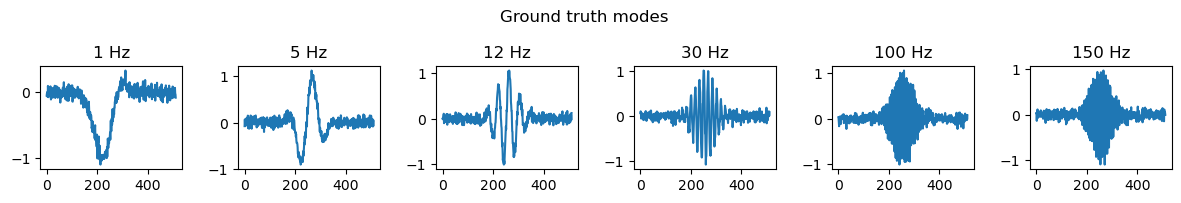

In [4]:
unique_freqs, freq_idx, freq_counts = np.unique(
    freq, return_index=True, return_counts=True
)
idx = freq_idx * wave_len
fig, ax = plt.subplots(1, freq_idx.size, figsize=(2*freq_idx.size,  2))
for i, t in enumerate(idx):
    ax[i].plot(T[t:t+wave_len])
    ax[i].set_title(f'{unique_freqs[i]} Hz')
plt.suptitle('Ground truth modes')
plt.tight_layout(h_pad=0, pad=0.9)

In [5]:
in_file = Path('../results/morlet/qsmp_m-512_sigma-1.0_2.0_4.0_8.0_16.0_rect-50_minfilt-128.npz')
with np.load(in_file) as data:
    density = data['density'].T
    NNdist = data['profile'].T
    NNindex = data['indices'].T

In [6]:
sigmas = [1.0, 2.0, 4.0, 8.0, 16.0]
sigmas = dict(zip(sigmas, np.arange(len(sigmas))))
interact(
    viz.show_density, density=fixed(density), sigma=sigmas, wave_len=fixed(wave_len), n_seg=(1, 10)
);

interactive(children=(Dropdown(description='sigma', options={1.0: 0, 2.0: 1, 4.0: 2, 8.0: 3, 16.0: 4}, value=0…

In [9]:
#XXX: This does NOT work on VS Code. It works fine on Chrome.
apps.modes_across_maxdist(T, wave_len, density,
                          NNindex, NNdist, sigmas)